# 5.2 Model Training & Stability Analysis

This notebook trains three classifiers on the preprocessed NSL-KDD dataset:

| Model | Encoding | Key property |
|---|---|---|
| K-Nearest Neighbours (KNN) | OHE (122 features) | Lazy learner, distance-based, K tuned via CV |
| Gaussian Naive Bayes (GNB) | LE (41 features) | Probabilistic, fast, assumes feature independence |
| SVM (RBF kernel) | OHE (122 features) | Margin-based, 25k stratified sample, threshold-tuned |

After training, **stability analysis** is performed using Repeated Stratified K-Fold CV (10×5 = 50 evaluations per model), followed by **learning curves**.

In [7]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from src.train import (
    train_knn, train_nb, train_svm,
    stability_analysis, compute_learning_curves
)

sns.set_theme(style="whitegrid", palette="muted")
REPORT_DIR = "../reports"
os.makedirs(REPORT_DIR, exist_ok=True)
print('Imports OK')

Imports OK


## Load Preprocessed Data

KNN and SVM use OHE (122 features). Naive Bayes uses LE (41 features). Both were saved by notebook 5.1.

In [8]:
# OHE — for KNN and SVM
X_train_ohe = pd.read_csv("../data/processed/X_train_ohe.csv")
X_test_ohe  = pd.read_csv("../data/processed/X_test_ohe.csv")

# LE — for Naive Bayes
X_train_le  = pd.read_csv("../data/processed/X_train_le.csv")
X_test_le   = pd.read_csv("../data/processed/X_test_le.csv")

# Labels (shared)
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"OHE — X_train: {X_train_ohe.shape}  X_test: {X_test_ohe.shape}")
print(f"LE  — X_train: {X_train_le.shape}   X_test: {X_test_le.shape}")
print(f"y_train: {y_train.value_counts().to_dict()}")
print(f"y_test : {y_test.value_counts().to_dict()}")

OHE — X_train: (125973, 122)  X_test: (22543, 122)
LE  — X_train: (125973, 41)   X_test: (22543, 41)
y_train: {0: 67343, 1: 58630}
y_test : {1: 12833, 0: 9710}


---
## Model 1 — K-Nearest Neighbours (OHE)

KNN classifies by majority vote among K nearest neighbours under Euclidean distance. OHE is used to eliminate false ordinal relationships between categorical values that would distort distance calculations.

**K selection:** odd values K ∈ {1, 3, 5, ..., 21} evaluated via 5-fold stratified CV on F1.

In [9]:
knn_model, knn_metrics, knn_cv_scores, best_k = train_knn(
    X_train_ohe, y_train, X_test_ohe, y_test,
    k_range=range(1, 22, 2)
)

[tune_knn] Testing K = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21] with 5-fold CV...
  K= 1  F1=0.9970 ± 0.0004
  K= 3  F1=0.9962 ± 0.0002
  K= 5  F1=0.9956 ± 0.0003
  K= 7  F1=0.9950 ± 0.0003
  K= 9  F1=0.9943 ± 0.0003
  K=11  F1=0.9939 ± 0.0006
  K=13  F1=0.9938 ± 0.0007
  K=15  F1=0.9934 ± 0.0006
  K=17  F1=0.9932 ± 0.0008
  K=19  F1=0.9931 ± 0.0007
  K=21  F1=0.9928 ± 0.0007

[tune_knn] Best K = 1  (F1 = 0.9970)
[train_knn] NOTE: K=1 selected. CV F1 will appear near-perfect because each training point is its own neighbour. Expect a larger train/test gap — document this as a limitation.

[train_knn] Fitting KNN with K=1...
[train_knn] Test results -> Acc: 0.7792  P: 0.9258  R: 0.6655  F1: 0.7744


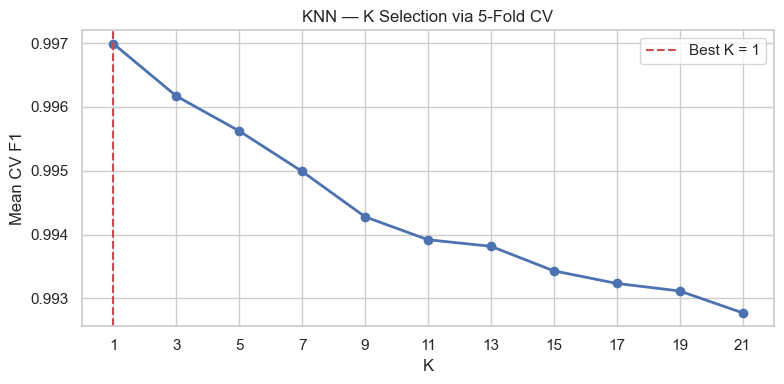

Best K = 1


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ks = list(knn_cv_scores.keys())
fs = list(knn_cv_scores.values())
ax.plot(ks, fs, marker="o", color="#4C72B0", linewidth=2)
ax.axvline(best_k, color="#C44E52", linestyle="--", label=f"Best K = {best_k}")
ax.set_xlabel("K")
ax.set_ylabel("Mean CV F1")
ax.set_title("KNN — K Selection via 5-Fold CV")
ax.legend()
ax.set_xticks(ks)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/knn_k_selection.png", dpi=150)
plt.show()
print(f"Best K = {best_k}")

---
## Model 2 — Gaussian Naive Bayes (LE)

GNB models each feature as a Gaussian conditioned on class label, classifying by maximum posterior probability. Label Encoding is kept because OHE produces binary 0/1 columns that violate the Gaussian assumption, collapsing F1 from 0.77 → 0.38.

No hyperparameters to tune — fits directly on the full training set.

In [11]:
nb_model, nb_metrics = train_nb(X_train_le, y_train, X_test_le, y_test)

[train_nb] Fitting Gaussian Naive Bayes...
[train_nb] Test results → Acc: 0.7709  P: 0.9161  R: 0.6578  F1: 0.7657


---
## Model 3 — Support Vector Machine (OHE, RBF kernel)

SVM finds the maximum-margin hyperplane in a kernel-induced feature space. OHE is used for the same reason as KNN — to prevent false ordinal relationships from corrupting the RBF kernel's distance computations.

**Runtime:** SVM is O(n²)–O(n³). We use a 25,000-instance stratified sample. Grid search: C ∈ {0.1, 1, 10} × gamma ∈ {scale, 0.01, 0.1}, 3-fold CV.

**Threshold tuning:** after fitting, the decision threshold is tuned to maximise Recall (NIDS priority) while keeping Precision ≥ 0.90.

In [12]:
svm_model, svm_metrics, svm_best_params, svm_sample, best_threshold, threshold_df = train_svm(
    X_train_ohe, y_train, X_test_ohe, y_test,
    sample_size=25000, cv=3
)
print(f"Best SVM params   : {svm_best_params}")
print(f"Best threshold    : {best_threshold}")

[train_svm] Sample size: 25,000  (Normal: 13,365  Attack: 11,635)
[train_svm] Running GridSearchCV (3-fold)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[train_svm] Best params: {'C': 10, 'gamma': 'scale'}  (CV F1 = 0.9856)
[train_svm] Tuning decision threshold for NIDS (target: recall, min_precision=0.90)...
[tune_threshold] Best threshold = 0.05  -> P=0.9160  R=0.7365  F1=0.8165  (optimised for recall, min_precision=0.9)
[train_svm] Test results (threshold=0.05) -> Acc: 0.8115  P: 0.9160  R: 0.7365  F1: 0.8165
Best SVM params   : {'C': 10, 'gamma': 'scale'}
Best threshold    : 0.05


---
## Results Summary — All Three Models

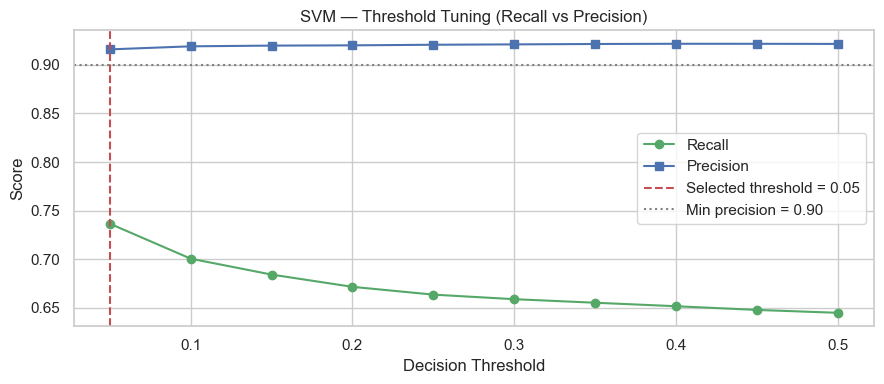

In [13]:
# Plot threshold sweep — Recall vs Precision tradeoff
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(threshold_df["threshold"], threshold_df["recall"],
        marker="o", color="#55A868", label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["precision"],
        marker="s", color="#4C72B0", label="Precision")
ax.axvline(best_threshold, color="#C44E52", linestyle="--",
           label=f"Selected threshold = {best_threshold}")
ax.axhline(0.90, color="gray", linestyle=":", label="Min precision = 0.90")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("SVM — Threshold Tuning (Recall vs Precision)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/svm_threshold_tuning.png", dpi=150)
plt.show()

In [14]:
results_df = pd.DataFrame([
    {"Model": "KNN",         **{k: v for k, v in knn_metrics.items() if k not in ['confusion_matrix','y_pred','threshold']}},
    {"Model": "Naive Bayes", **{k: v for k, v in nb_metrics.items()  if k not in ['confusion_matrix','y_pred','threshold']}},
    {"Model": "SVM",         **{k: v for k, v in svm_metrics.items() if k not in ['confusion_matrix','y_pred','threshold']}},
]).set_index("Model")

results_df = results_df[["accuracy","precision","recall","f1"]]
results_df.columns = ["Accuracy","Precision","Recall","F1"]
print(results_df.round(4).to_string())

             Accuracy  Precision  Recall      F1
Model                                           
KNN            0.7792     0.9258  0.6655  0.7744
Naive Bayes    0.7709     0.9161  0.6578  0.7657
SVM            0.8115     0.9160  0.7365  0.8165


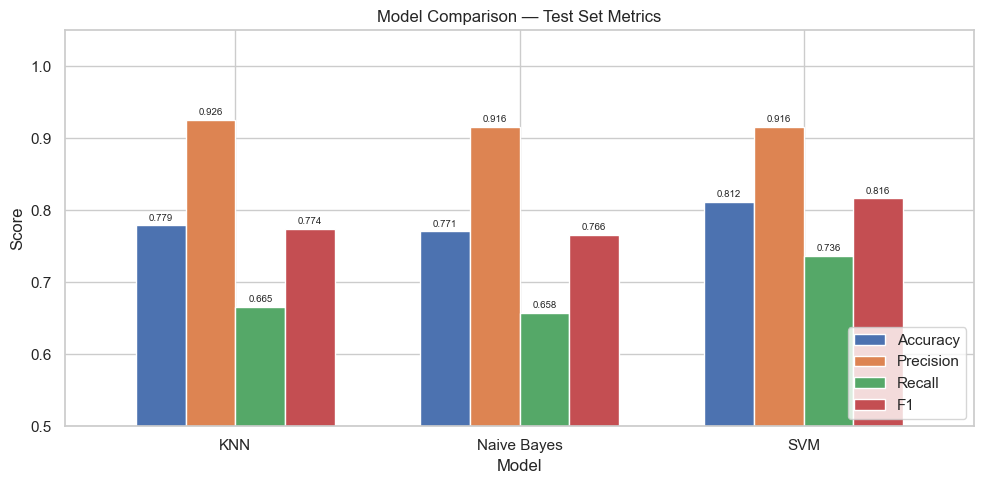

In [15]:
# Grouped bar chart
ax = results_df.plot(kind="bar", figsize=(10, 5), rot=0,
                     color=["#4C72B0","#DD8452","#55A868","#C44E52"],
                     edgecolor="white", width=0.7)
ax.set_ylim(0.5, 1.05)
ax.set_title("Model Comparison — Test Set Metrics")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/model_comparison.png", dpi=150)
plt.show()

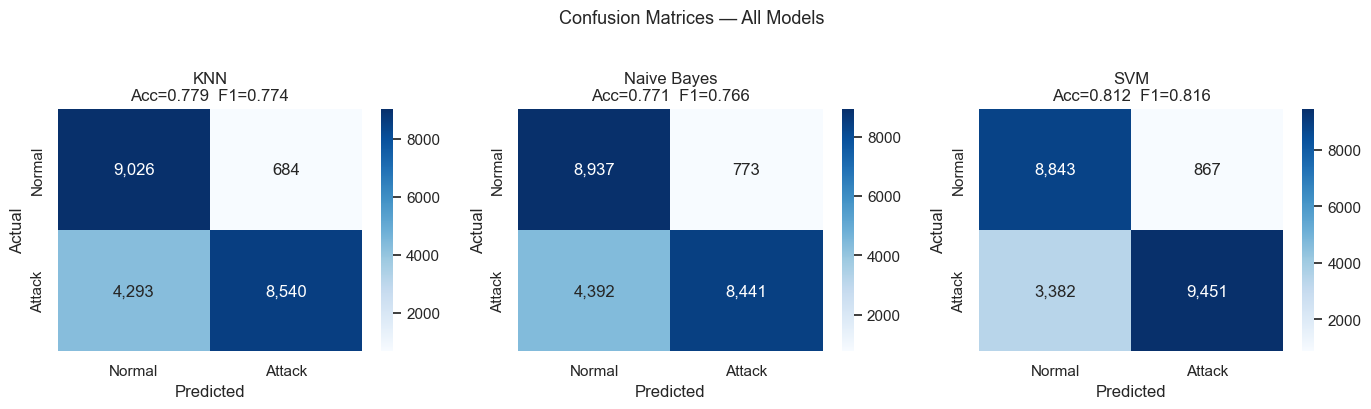

In [16]:
# Confusion matrices — side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
model_names = ["KNN", "Naive Bayes", "SVM"]
all_metrics = [knn_metrics, nb_metrics, svm_metrics]

for ax, name, m in zip(axes, model_names, all_metrics):
    cm = m["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
                xticklabels=["Normal","Attack"],
                yticklabels=["Normal","Attack"])
    ax.set_title(f"{name}\nAcc={m['accuracy']:.3f}  F1={m['f1']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Stability Analysis — Repeated Stratified K-Fold

10 repeats × 5 folds = **50 evaluations per model**. Reports Mean F1, Std, and CV% (std/mean × 100). CV% < 2% = very stable.

**Note:** KNN and SVM use their OHE data; Naive Bayes uses LE data.

In [ ]:
# KNN and SVM stability on OHE data
stability_models_ohe = {
    "KNN": KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1),
    "SVM": SVC(kernel="rbf", C=svm_best_params["C"],
               gamma=svm_best_params["gamma"],
               class_weight="balanced", random_state=42),
}

stability_ohe, raw_scores_ohe = stability_analysis(
    stability_models_ohe, X_train_ohe, y_train,
    n_splits=5, n_repeats=10, scoring="f1", svm_sample_size=25000
)

# Naive Bayes stability on LE data
stability_models_le = {"Naive Bayes": GaussianNB()}
stability_le, raw_scores_le = stability_analysis(
    stability_models_le, X_train_le, y_train,
    n_splits=5, n_repeats=10, scoring="f1"
)

# Combine into one table
stability_df = pd.concat([stability_ohe, stability_le], ignore_index=True)
raw_scores   = {**raw_scores_ohe, **raw_scores_le}

print("\nStability Summary (10×5 Repeated Stratified K-Fold):")
print(stability_df.set_index("Model").to_string())

[stability] Running 10×5-fold CV for KNN...
  → Mean=0.9970  Std=0.0003  CV%=0.03%
[stability] Running 10×5-fold CV for SVM...


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_order = ["KNN", "Naive Bayes", "SVM"]
score_data = [raw_scores[m] for m in plot_order]
colors     = ["#4C72B0", "#DD8452", "#55A868"]

bp = ax.boxplot(score_data, patch_artist=True, notch=True,
                medianprops=dict(color="black", linewidth=2))

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for i, scores in enumerate(score_data, start=1):
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(scores))
    ax.scatter(np.full(len(scores), i) + jitter, scores,
               alpha=0.3, s=12, color=colors[i-1])

ax.set_xticks(range(1, len(plot_order)+1))
ax.set_xticklabels(plot_order)
ax.set_ylabel("F1 Score")
ax.set_title("Stability Analysis — F1 Distribution (10×5 Repeated Stratified K-Fold)\n"
             "Each point = one fold evaluation (50 total per model)")
ax.set_ylim(0.7, 1.02)

for i, model in enumerate(plot_order):
    row = stability_df[stability_df["Model"] == model].iloc[0]
    ax.text(i+1, 0.715, f"CV%={row['CV%']}",
            ha="center", fontsize=9, color="#333333")

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/stability_boxplot.png", dpi=150)
plt.show()

---
## Learning Curves

Learning curves show how F1 changes as the training set size increases. They reveal:
- **High bias (underfitting):** both train and val F1 are low and plateau early
- **High variance (overfitting):** large gap between train F1 (high) and val F1 (low)
- **Good fit:** train and val F1 converge at a high value

Note: SVM learning curves use a capped subset for runtime feasibility.

In [ ]:
# KNN on OHE
curves = compute_learning_curves(
    {"KNN": KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)},
    X_train_ohe, y_train,
    train_sizes=np.linspace(0.05, 1.0, 8), cv=5, scoring="f1"
)

# Naive Bayes on LE
nb_curves = compute_learning_curves(
    {"Naive Bayes": GaussianNB()},
    X_train_le, y_train,
    train_sizes=np.linspace(0.05, 1.0, 8), cv=5, scoring="f1"
)
curves.update(nb_curves)

# SVM on OHE 25k sample
X_samp, y_samp = svm_sample
svm_curves = compute_learning_curves(
    {"SVM": SVC(kernel="rbf", C=svm_best_params["C"],
                gamma=svm_best_params["gamma"],
                class_weight="balanced", random_state=42)},
    X_samp, y_samp,
    train_sizes=np.linspace(0.1, 1.0, 6), cv=3, scoring="f1"
)
curves.update(svm_curves)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_map = {"KNN": "#4C72B0", "Naive Bayes": "#DD8452", "SVM": "#55A868"}

for ax, (name, (ts, tr, val)) in zip(axes, curves.items()):
    c = colors_map[name]
    tr_mean,  tr_std  = tr.mean(axis=1),  tr.std(axis=1)
    val_mean, val_std = val.mean(axis=1), val.std(axis=1)
    ax.plot(ts, tr_mean,  "o-",  color=c, label="Train F1")
    ax.plot(ts, val_mean, "s--", color=c, label="CV Val F1", alpha=0.7)
    ax.fill_between(ts, tr_mean-tr_std,  tr_mean+tr_std,  alpha=0.1, color=c)
    ax.fill_between(ts, val_mean-val_std, val_mean+val_std, alpha=0.1, color=c)
    ax.set_title(f"{name} — Learning Curve")
    ax.set_xlabel("Training samples")
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0.5, 1.05)
    ax.legend()

plt.suptitle("Learning Curves — All Models", fontsize=13)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 5.2 Summary

In [ ]:
print("=" * 60)
print("  SECTION 5.2 COMPLETE")
print("=" * 60)
print(f"  Best K (KNN)        : {best_k}")
print(f"  Best SVM params     : {svm_best_params}")
print(f"  Best SVM threshold  : {best_threshold}")
print()
print("  Test Set Metrics:")
print(results_df.round(4).to_string())
print()
print("  Stability (10x5 RSKF):")
print(stability_df.set_index("Model")[["Mean F1","Std","CV%"]].to_string())
print()
print("  Plots saved to ../reports/:")
for f in ["knn_k_selection", "svm_threshold_tuning", "model_comparison",
          "confusion_matrices", "stability_boxplot", "learning_curves"]:
    print(f"    {f}.png")
print("=" * 60)
print("  Next: run notebooks/5_3_evaluation.ipynb")